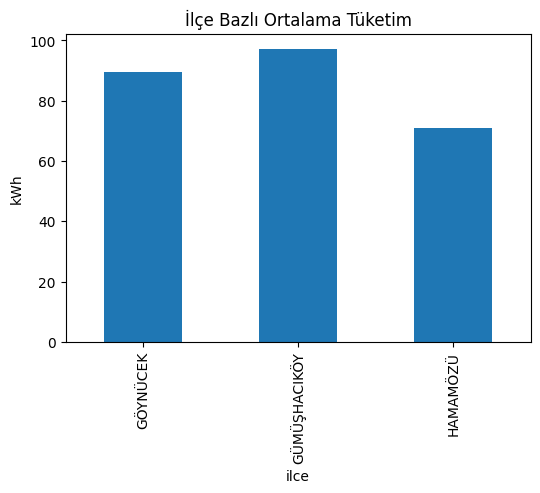

In [ ]:
#İlçe Karşılaştırma
ilce_ort = df_all.groupby("ilce")["kwh"].mean()

plt.figure(figsize=(6,4))
ilce_ort.plot(kind="bar")
plt.title("İlçe Bazlı Ortalama Tüketim")
plt.ylabel("kWh")
plt.show()

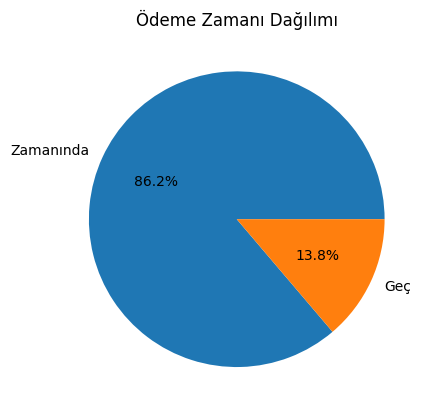

In [ ]:
#Ödeme Zaman Analizi

is_zamaninda = df_tahsilat_1['Son Ödeme Tarihinden Önceki Tahsilat'].notna() | \
               df_tahsilat_1['Son Ödeme Tarihindeki Tahsilat'].notna()
zamaninda = is_zamaninda.sum()

late_cols = [col for col in df_tahsilat_1.columns if col.startswith('Son Ödeme (')]
is_gec = df_tahsilat_1[late_cols].notna().any(axis=1)

gec = (is_gec & ~is_zamaninda).sum()

plt.pie([zamaninda, gec], labels=["Zamanında","Geç"], autopct="%1.1f%%")
plt.title("Ödeme Zamanı Dağılımı")
plt.show()

In [ ]:
#Müşteri Segmentasyonu
df_customer = df_all.groupby("sozlesme_hesap_no")["kwh"].mean().reset_index()

df_customer["segment"] = pd.qcut(df_customer["kwh"], 4, labels=["Düşük","Orta","Yüksek","Çok Yüksek"])

df_customer["segment"].value_counts()

,count
segment,
Düşük,7073
Çok Yüksek,7073
Orta,7072
Yüksek,7072
